### Importing necessary modules

In [ ]:
import pandas as pd                                                                     
import matplotlib.pyplot as plt                                                         
import seaborn as sns                                                                   
import numpy as np                                                                      
import tensorflow as tf                                                                 
import matplotlib as mpl                                                                
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
mpl.rcParams['figure.figsize'] = (9, 7)
from joblib import dump, load                                                           
import random                                                                           
import cartopy.crs as ccrs                                                              
import cartopy.feature as cfeature                                                      
from netCDF4 import Dataset                                                             

In [ ]:
geodata = Dataset("/home/mendrika/mendrika-phd/codes/nflics/geoloc_grids/nxny1640_580_nxnyds164580_blobdx0.04491576_area4_n23_20_32.nc")

xmin = 65
ymin = 220
xmax = 750
ymax = 500

lons = geodata["lons_mid"][ymin:ymax, xmin:xmax]
lats = geodata["lats_mid"][ymin:ymax, xmin:xmax]

In [ ]:
longitude = np.arange(-20, -12, 0.1)
latitude = np.arange(11, 19, 0.1)

lons, lats = np.meshgrid(longitude, latitude)

In [ ]:
Dakar_lon = -17.467686
Dakar_lat = 14.716677

In [ ]:
import sys
sys.path.insert(1, "/home/mendrika/mendrika-phd/codes/nflics")
import nflics  

### Importing dataset

### Exploratory data analysis

In [ ]:
def log_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i > 0:
                transformed.append(np.log(i))
            else:
                transformed.append(np.log(i+1e-8))    
        df_copy[key] = transformed
    return df_copy

In [ ]:
def sqrt_transform(df, keys):
    df_copy = df.copy()    
    for key in keys:
        transformed = []
        for i in df_copy[key]:
            if i >= 0:
                transformed.append(np.sqrt(i)) 
        df_copy[key] = transformed
    return df_copy

In [ ]:
# Presence or absence of convection in Dakar at time t+1
target_index = "Cb_Dakar"

# Input at time t0
t0 = "year,month,day,hour,minute,"

# latitude and longitude, wavelet power, storm size and distance to Dakar
location = ""
wavelet_power = ""
storm_size = ""
distance = ""
for i in range(1,6):
    location += f"lat{i},lon{i},"
    wavelet_power += f"wp{i},"
    distance += f"ds{i},"
    storm_size += f"size{i},"

# combining all fields to form the feature input
features = t0 + location + wavelet_power + storm_size + distance
field =  features + target_index
field = field.split(',')

In [ ]:
to_scale = wavelet_power + storm_size + distance

In [ ]:
lead_time = 1

In [ ]:
model = tf.keras.models.load_model(f"/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/Dakar-t{lead_time}.keras")

In [ ]:
scaler = load(f'/home/mendrika/mendrika-phd/codes/nflics/model-ML-Dakar/lead-time/Dakar-t{lead_time}.bin')

Computing the average wavelet power

In [ ]:
mean_wp = 3430.40
median_wp = 2266.0

mean_size = 7460.30
median_size = 5000.0

In [ ]:
def create_storm():
    return {
        'year': [], 
        'month': [], 
        'day': [], 
        'hour': [], 
        'minute': [], 
        'lat1': [], 
        'lon1': [], 
        'lat2': [], 
        'lon2': [], 
        'lat3': [], 
        'lon3': [], 
        'lat4': [], 
        'lon4': [], 
        'lat5': [], 
        'lon5': [], 
        'wp1': [], 
        'wp2': [], 
        'wp3': [], 
        'wp4': [], 
        'wp5': [], 
        'size1': [], 
        'size2': [], 
        'size3': [], 
        'size4': [], 
        'size5': [], 
        'ds1': [], 
        'ds2': [], 
        'ds3': [], 
        'ds4': [], 
        'ds5': [], 
    }

For reproducibility

In [ ]:
rng1 = np.random.RandomState(26)
rng2 = np.random.RandomState(21)
def generate_geo_coords(lat_min, lat_max, lon_min, lon_max):
    artificial_storm_lat = round(rng1.uniform(lat_min, lat_max), 6)
    artificial_storm_lon = round(rng1.uniform(lon_min, lon_max), 6)
    return artificial_storm_lat, artificial_storm_lon

In [ ]:
def distance_to_Dakar(lat, lon):
    Dakar_lon = -17.467686
    Dakar_lat = 14.716677
    Dakar_y, Dakar_x = nflics.X0(Dakar_lat, Dakar_lon)
    y, x = nflics.X0(lat, lon)
    return round(np.sqrt((y - Dakar_y)**2 + (x - Dakar_x)**2), 4)

In [ ]:
number_of_data_points = 1
number_of_storms_to_generate = 1
number_of_storms_in_model = 5

In [ ]:
def generate_a_storm_cluster():
    lat_center, lon_center = generate_geo_coords(10, 19, -18.2, -10)
    lat_clusters = []
    lon_clusters = []    
    for _ in range(5):
        lat_candidate = lat_center + random.normalvariate(0,0.2)    
        lat_clusters.append(lat_candidate)    
        lon_candidate = lon_center + random.normalvariate(0,0.2)
        lon_clusters.append(lon_candidate)
    return lat_center, lon_center, lat_clusters, lon_clusters

In [ ]:
def generate_storm_cluster_from_a_center(lat_center, lon_center):    
    lat_clusters = []
    lon_clusters = []    
    for _ in range(5):
        lat_candidate = lat_center + random.normalvariate(0,0.2)    
        lat_clusters.append(lat_candidate)    
        lon_candidate = lon_center + random.normalvariate(0,0.2)
        lon_clusters.append(lon_candidate)
    return lat_clusters, lon_clusters

In [ ]:
raw_artificial_storm_data = pd.read_csv("test-data-from-latlon-map.csv")

In [ ]:
artificial_storm_data = log_transform(raw_artificial_storm_data, to_scale.split(',')[:-1])
artificial_storm_data = sqrt_transform(artificial_storm_data, t0.split(',')[:-1])
x_new = artificial_storm_data[raw_artificial_storm_data.keys()]
x_new_std = scaler.transform(x_new)
y_new_pred = model.predict(x_new_std)

 98/200 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


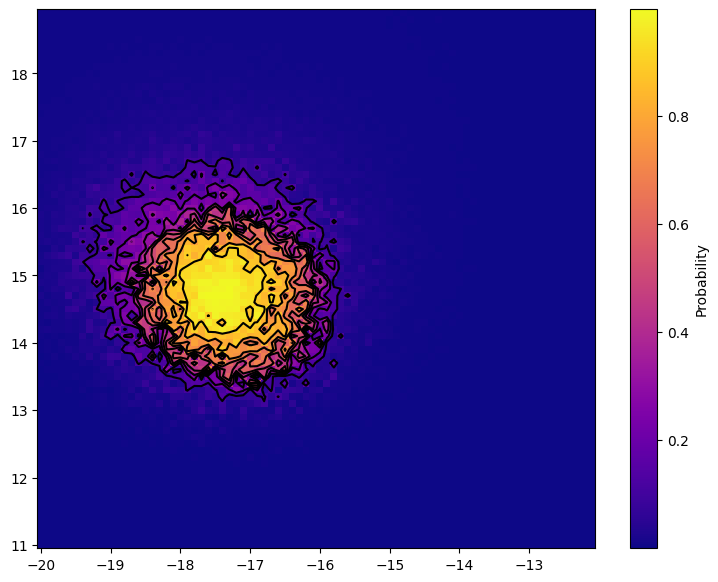

In [ ]:
prob = y_new_pred.flatten().reshape(lons.shape).round(4)
plt.pcolormesh(lons, lats, prob, cmap="plasma")
plt.colorbar(label='Probability')
contour = plt.contour(lons, lats, prob, colors='black', levels=10)
#plt.clabel(contour, inline=True, fontsize=8, fmt='%d')
plt.show()

In [ ]:
from scipy.ndimage import gaussian_filter  

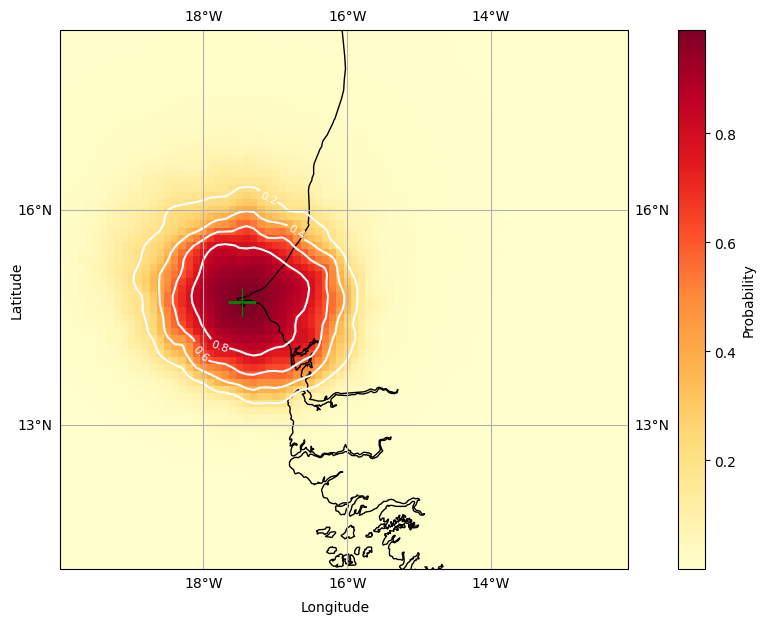

In [ ]:
fig = plt.figure(figsize=(13, 7))

ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([-20, -12.1, 11, 18.5], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, edgecolor='gray')
#ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.COASTLINE)
ax.gridlines(xlocs=np.array([-18, -16, -14]), ylocs=np.array([10, 13, 16]), draw_labels=True, crs=ccrs.PlateCarree())

prob = gaussian_filter(prob, sigma=1)

plt.pcolormesh(lons, lats, prob, cmap="YlOrRd")
plt.colorbar(label='Probability')
contour = plt.contour(lons, lats, prob, colors='white', levels=5)
plt.plot(-17.4677, 14.7167, marker="+", color="green", markersize=20)
plt.clabel(contour, inline=True, fontsize=8)

fig.text(0.52, 0.05, "Longitude", ha='center')
fig.text(0.27, 0.51, "Latitude", va='center', rotation='vertical')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
#plt.title('Probability of storm in Dakar at t0+1h given a storms location at t0')
plt.show()
plt.show()